In [107]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [108]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()

In [109]:
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [110]:
print(itos)
print(stoi)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [111]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [112]:
block_size = 8

def build_dataset(words):
    X, Y = [], []
    for word in words:
        context = [0] * block_size
        for ch in word + '.':
            ch_index = stoi[ch]
            X.append(context)
            Y.append(ch_index)
            context = context[1:] + [ch_index]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, Y_train = build_dataset(words[:n1])
X_dev, Y_dev = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [113]:
for x,y in zip(X_train[:20], Y_train[:20]):
    print("Kontext X: ", "".join(itos[ix.item()] for ix in x), "-> Index Y: ", y.item())

Kontext X:  ........ -> Index Y:  25
Kontext X:  .......y -> Index Y:  21
Kontext X:  ......yu -> Index Y:  8
Kontext X:  .....yuh -> Index Y:  5
Kontext X:  ....yuhe -> Index Y:  14
Kontext X:  ...yuhen -> Index Y:  7
Kontext X:  ..yuheng -> Index Y:  0
Kontext X:  ........ -> Index Y:  4
Kontext X:  .......d -> Index Y:  9
Kontext X:  ......di -> Index Y:  15
Kontext X:  .....dio -> Index Y:  14
Kontext X:  ....dion -> Index Y:  4
Kontext X:  ...diond -> Index Y:  18
Kontext X:  ..diondr -> Index Y:  5
Kontext X:  .diondre -> Index Y:  0
Kontext X:  ........ -> Index Y:  24
Kontext X:  .......x -> Index Y:  1
Kontext X:  ......xa -> Index Y:  22
Kontext X:  .....xav -> Index Y:  9
Kontext X:  ....xavi -> Index Y:  5


In [114]:
from typing import Any


class Linear:
    def __init__(self, fan_in, fan_out, bias=True) -> None:
        self.weights = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x) -> Any:
        self.out = x @ self.weights
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weights] + ([] if self.bias is None else [self.bias])

class Tanh:
    def __call__(self, x):
       self.out = torch.tanh(x)
       return self.out
    def parameters(self):
       return []

class Embedding:
    # PyTorch indexing rule: 
    # When you index a tensor with a tensor of integers, the result's shape is IX.shape + weight.shape[1:].
    # Örnek kullanim:
    # IX.shape = (1, 3): batch of 1, 3 characters of context.
    # weight.shape = (27, 10), so each row has 10 numbers.
    # Result: (1, 3) + (10,) = (1, 3, 10).


    # num_embeddings = vocab_size
    def __init__(self, num_embeddings, emb_dim) -> None:
       self.weight = torch.randn((num_embeddings, emb_dim))

    def __call__(self, IX) -> Any:
       self.out = self.weight[IX]
       return self.out

    def parameters(self):
       return [self.weight]

# WaveNet'ten gelme fikir
class FlattenConsecutive:
    def __init__(self, n) -> None:
        self.n = n
    def __call__(self, x) -> Any:
        B,T,C = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out

    def parameters(self):
        return []

class Sequential:
    def __init__(self, layers) -> None:
      self.layers = layers
    def __call__(self, x) -> Any:
       for layer in self.layers:
          x = layer(x)
       self.out = x
       return self.out
    def parameters(self):
       return [parameter for layer in self.layers for parameter in layer.parameters()]
     
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
      self.eps = eps
      self.momentum = momentum
      self.training = True
      # parameters (trained with backprop)
      self.gamma = torch.ones(dim)
      self.beta = torch.zeros(dim)
      # buffers (trained with a running 'momentum update')
      self.running_mean = torch.zeros(dim)
      self.running_var = torch.ones(dim)
    
    def __call__(self, x):
      # calculate the forward pass
      if self.training:
        if x.ndim == 2:
          dim = 0
        elif x.ndim == 3:
          dim = (0,1)
        xmean = x.mean(dim, keepdim=True) # batch mean
        xvar = x.var(dim, keepdim=True) # batch variance
      else:
        xmean = self.running_mean
        xvar = self.running_var
      xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
      self.out = self.gamma * xhat + self.beta
      # update the buffers
      if self.training:
        with torch.no_grad():
          self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
          self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
      return self.out
    
    def parameters(self):
      return [self.gamma, self.beta]

In [115]:
x = torch.arange(400)

x = x.view(5, 8, 10)
print(x)


tensor([[[  0,   1,   2,   3,   4,   5,   6,   7,   8,   9],
         [ 10,  11,  12,  13,  14,  15,  16,  17,  18,  19],
         [ 20,  21,  22,  23,  24,  25,  26,  27,  28,  29],
         [ 30,  31,  32,  33,  34,  35,  36,  37,  38,  39],
         [ 40,  41,  42,  43,  44,  45,  46,  47,  48,  49],
         [ 50,  51,  52,  53,  54,  55,  56,  57,  58,  59],
         [ 60,  61,  62,  63,  64,  65,  66,  67,  68,  69],
         [ 70,  71,  72,  73,  74,  75,  76,  77,  78,  79]],

        [[ 80,  81,  82,  83,  84,  85,  86,  87,  88,  89],
         [ 90,  91,  92,  93,  94,  95,  96,  97,  98,  99],
         [100, 101, 102, 103, 104, 105, 106, 107, 108, 109],
         [110, 111, 112, 113, 114, 115, 116, 117, 118, 119],
         [120, 121, 122, 123, 124, 125, 126, 127, 128, 129],
         [130, 131, 132, 133, 134, 135, 136, 137, 138, 139],
         [140, 141, 142, 143, 144, 145, 146, 147, 148, 149],
         [150, 151, 152, 153, 154, 155, 156, 157, 158, 159]],

        [[160, 161, 

In [116]:
torch.manual_seed(42); 

In [117]:
vocab_size = len(stoi) # num_embeddings
embedding_dim = 10
batch_size = 32
context_length = 8
hidden_dims = 300

In [ ]:
# 2. Sinir Agi - WaveNet

embedding_dim = 24
hidden_dims = 128
model2 = Sequential([
    # => (32, 8)
    Embedding(vocab_size, embedding_dim), # => (32, 8, 24)
    FlattenConsecutive(2), # => (32, 4, 48)
    Linear(48, 128), # => (32, 4, 128)
    BatchNorm1d(hidden_dims), # => (32, 4, 128)
    Tanh(), # => (32, 4, 128)
    FlattenConsecutive(2), # => (32, 2, 256)
    Linear(256, 128),
    BatchNorm1d(hidden_dims), # => (32, 2, 128)
    Tanh(), # => (32, 2, 128)
    FlattenConsecutive(2), # => (32, 1, 256) == (32, 256)
    Linear(256, 128), # (32, 128)
    BatchNorm1d(hidden_dims), # => (32, 128)
    Tanh(), # => (32, 128)
    Linear(128, vocab_size) # => (32, 27)
])

params2 = model2.parameters()
num_params_model2 = sum(p.nelement() for p in params2)

with torch.no_grad():
  model2.layers[-1].weights *= 0.1 # last layer make less confident

for p in params2:
    p.requires_grad = True

print(f"num_params_model2: {num_params_model2}")


num_params_model2: 76963


In [121]:
max_steps = 20000
batch_size = 32
lossi = []
for i in range(max_steps):
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    Xb, Yb = X_train[ix], Y_train[ix] # batch X,Y

    logits = model2(Xb)
    loss = F.cross_entropy(logits, Yb)

    for p in params2:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in params2:
        p.data += -lr * p.grad


    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/  20000: 3.3140
  10000/  20000: 1.9346


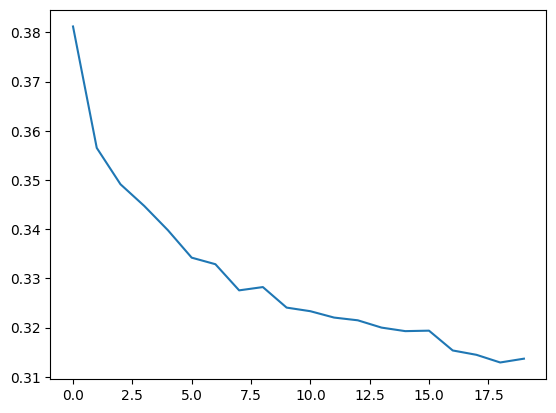

In [122]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [123]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model2.layers:
  layer.training = False

In [124]:
# evaluate the loss - Model 2
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (X_train, Y_train),
    'val': (X_dev, Y_dev),
    'test': (X_test, Y_test),
  }[split]
  logits = model2(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0569090843200684
val 2.110893726348877


In [125]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model2(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

abarielie.
alley.
malelli.
evenlon.
karleecy.
nareli.
marvin.
acian.
iloah.
jostis.
slort.
jakyson.
breelyn.
kaylanie.
avere.
ranty.
makhaya.
dayda.
amyaa.
zahii.


In [126]:
print(f"num_params_model2: {num_params_model2}")

num_params_model2: 76963
